
# Assignment 2 (Option 2): House Prices; End-to-End ML Pipeline (XGBoost)
**Author:** Eshika Chowdhury - 24878821  

**Subject:** Advanced Data Analytics Algorithms (ADAA)  

**Notebook Purpose:** Self-contained pipeline that downloads data from the web (GitHub), preprocesses, trains, tunes, evaluates, and produces a submission for the House Prices regression task.

**Github Repo:** https://github.com/eshikachowdhury/ADAA

Dataset Used: https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques


### A. Task Definition (I/O Interface)
- **Objective:** Predict `SalePrice` (continuous) for houses.
- **Training Input:** Tabular features (79 numeric/categorical columns after cleaning).
- **Training Output:** Model parameters minimizing **RMSE on `log(SalePrice)`**.
- **Deployment Input:** New house features with same schema (columns) as training features.
- **Deployment Output:** A single predicted sale price (dollars).



### B. Explanation of Model, Algorithm, Key Components
- **System Overview:** Data loading, EDA (types, missingness, skew), Imputation, Skew correction, One-Hot Encoding, Train/Validation split, XGBoost, CV, HPO, Final model, Feature importance.
- **Key Choices:**
  - One-Hot Encode categoricals (XGBoost expects numeric matrices).
  - Log-transform target to match competition metric and equalize proportional errors.
  - Fix skewed numeric features with `log1p` where needed.
- **Theory to Code:**
  - Loss: RMSE on log-scale is implemented via `mean_squared_error` on `log(SalePrice)`.
  - Boosting: `n_estimators`, `learning_rate`, `max_depth`, regularisation (`reg_lambda`, `reg_alpha`).



### C. Model Evaluation & Refinement
- **Metrics:** log-RMSE (primary), R² (secondary on validation).
- **Validation:** 5-fold CV (mean ± std). Robustness check vs single split.
- **Reflections:** Document baseline vs tuned improvements; discuss limitations and next steps.

In [3]:
# ==== Setup & Imports ====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew

from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

pd.set_option('display.max_columns', 200)
print("Libraries imported.")


Libraries imported.




## 1) Data Loading (Self-contained from GitHub)


In [4]:
train_url = "https://raw.githubusercontent.com/eshikachowdhury/ADAA/refs/heads/main/train.csv"
test_url  = "https://raw.githubusercontent.com/eshikachowdhury/ADAA/refs/heads/main/test.csv"

# Load
train_df = pd.read_csv(train_url)
test_df  = pd.read_csv(test_url)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()

Train shape: (1460, 81)
Test shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



## 2) Exploratory Checks (Types, Missingness, Skew)
We inspect dtypes, missing values, and skewness to **justify** preprocessing choices.


In [5]:

# Types & non-null counts
print("=== train.info() ===")
print(train_df.info())


=== train.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   

In [6]:

# Missing values overview
missing_counts = train_df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing_counts / len(train_df) * 100).round(2)
missing_summary = pd.DataFrame({"missing": missing_counts, "pct": missing_pct})
print("=== Top 20 columns by missingness ===")
print(missing_summary.head(20))


=== Top 20 columns by missingness ===
              missing    pct
PoolQC           1453  99.52
MiscFeature      1406  96.30
Alley            1369  93.77
Fence            1179  80.75
MasVnrType        872  59.73
FireplaceQu       690  47.26
LotFrontage       259  17.74
GarageQual         81   5.55
GarageFinish       81   5.55
GarageType         81   5.55
GarageYrBlt        81   5.55
GarageCond         81   5.55
BsmtFinType2       38   2.60
BsmtExposure       38   2.60
BsmtCond           37   2.53
BsmtQual           37   2.53
BsmtFinType1       37   2.53
MasVnrArea          8   0.55
Electrical          1   0.07
Condition2          0   0.00


In [ ]:

# Identify categorical vs numerical before target separation
cat_cols = train_df.select_dtypes(include=["object"]).columns.tolist()
num_cols = train_df.select_dtypes(exclude=["object"]).columns.tolist()
print(f"Categorical features: {len(cat_cols)}")
print(cat_cols[:15], "...")
print(f"Numerical features: {len(num_cols)}")
print(num_cols[:15], "...")


In [7]:

# Skewness for numeric columns (will recompute after dropping target)
train_numeric_only = train_df.select_dtypes(exclude=["object"]).drop(columns=["SalePrice"], errors="ignore")
skewness_series = train_numeric_only.apply(lambda x: skew(x.dropna()))
high_skew = skewness_series[skewness_series > 0.75].sort_values(ascending=False)
print("=== Highly skewed numeric features (> 0.75) ===")
print(high_skew.head(20))



=== Highly skewed numeric features (> 0.75) ===
MiscVal          24.451640
PoolArea         14.813135
LotArea          12.195142
3SsnPorch        10.293752
LowQualFinSF      9.002080
KitchenAbvGr      4.483784
BsmtFinSF2        4.250888
ScreenPorch       4.117977
BsmtHalfBath      4.099186
EnclosedPorch     3.086696
MasVnrArea        2.666326
OpenPorchSF       2.361912
LotFrontage       2.160866
BsmtFinSF1        1.683771
WoodDeckSF        1.539792
TotalBsmtSF       1.522688
MSSubClass        1.406210
1stFlrSF          1.375342
GrLivArea         1.365156
BsmtUnfSF         0.919323
dtype: float64



## 3) Preprocessing
Steps:
1. Separate target and drop `Id`.
2. Impute missing values (median for numeric; `"None"` for categoricals).
3. **Skew correction** (`log1p`) on highly skewed numeric features.
4. **One-Hot Encode** categoricals and **align** train/test columns.
5. Keep everything numeric for XGBoost.



In [8]:

# 3.1 Separate target and IDs
y = np.log1p(train_df["SalePrice"])  # log-transform target for metric alignment
train_ids = train_df["Id"]
test_ids  = test_df["Id"]

X_raw = train_df.drop(columns=["SalePrice", "Id"])
test_raw = test_df.drop(columns=["Id"])

# 3.2 Impute missing values
for col in X_raw.columns:
    if X_raw[col].dtype == "object":
        X_raw[col] = X_raw[col].fillna("None")
        test_raw[col] = test_raw[col].fillna("None")
    else:
        X_raw[col] = X_raw[col].fillna(X_raw[col].median())
        test_raw[col] = test_raw[col].fillna(test_raw[col].median())

# 3.3 Skew correction on numeric features
num_cols = X_raw.select_dtypes(exclude=["object"]).columns
sk_values = X_raw[num_cols].apply(lambda x: skew(x.dropna()))
skewed_feats = sk_values[sk_values > 0.75].index

for col in skewed_feats:
    X_raw[col] = np.log1p(X_raw[col])
    if col in test_raw.columns:
        test_raw[col] = np.log1p(test_raw[col])

# 3.4 One-Hot Encode categoricals and align
X = pd.get_dummies(X_raw, drop_first=True)
X_test = pd.get_dummies(test_raw, drop_first=True)

X, X_test = X.align(X_test, join="left", axis=1, fill_value=0)

print("After preprocessing:")
print("X shape:", X.shape, "X_test shape:", X_test.shape)
print("Dtypes:", X.dtypes.value_counts())



After preprocessing:
X shape: (1460, 260) X_test shape: (1459, 260)
Dtypes: bool       224
float64     22
int64       14
Name: count, dtype: int64



## 4) Train/Validation Split



In [9]:

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.20, random_state=42
)
X_train.shape, X_valid.shape

((1168, 260), (292, 260))


## 5) Baseline Model - XGBoost (reasoned choice)
**Why XGBoost?** Gradient-boosted trees are state-of-the-art for **tabular** data, capture nonlinear interactions, handle sparse OHE features well, and are robust with minimal scaling.



In [10]:
baseline_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_valid)
rmse  = np.sqrt(mean_squared_error(y_valid, y_pred))
r2    = r2_score(y_valid, y_pred)

print(f"Baseline log-RMSE: {rmse:.5f}")
print(f"Baseline R^2:      {r2:.5f}")

Baseline log-RMSE: 0.13251
Baseline R^2:      0.90591



## 6) Cross-Validation (5-fold) - Robustness Check



In [11]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = np.sqrt(-cross_val_score(
    baseline_model, X, y, scoring="neg_mean_squared_error", cv=kf, n_jobs=-1
))
print("CV log-RMSE scores:", np.round(cv_scores, 5))
print(f"Mean CV log-RMSE: {cv_scores.mean():.5f} ± {cv_scores.std():.5f}")

CV log-RMSE scores: [0.13577 0.11599 0.16104 0.13257 0.10906]
Mean CV log-RMSE: 0.13089 ± 0.01808



## 7) Hyperparameter Tuning (RandomizedSearchCV)
We tune key parameters to improve generalisation and log-RMSE.



In [12]:
param_dist = {
    "n_estimators": [500, 800, 1000, 1500],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_lambda": [0, 1, 5, 10],
    "reg_alpha": [0, 1, 5, 10]
}

search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=25,
    scoring="neg_root_mean_squared_error",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X, y)
best_rmse = -search.best_score_
best_params = search.best_params_

print("Best params:", best_params)
print(f"Best CV log-RMSE: {best_rmse:.5f}")

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best params: {'subsample': 0.8, 'reg_lambda': 0, 'reg_alpha': 0, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.6}
Best CV log-RMSE: 0.12374



## 8) Final Model (fit on full training) & Submission
We refit the best model on all training data, predict on test, reverse log, and save `submission.csv`.



In [13]:
best_model = search.best_estimator_
best_model.fit(X, y)

test_preds_log = best_model.predict(X_test)
test_preds = np.expm1(test_preds_log)  # back to dollar scale

submission = pd.DataFrame({"Id": test_ids, "SalePrice": test_preds})
submission.to_csv("submission.csv", index=False)
print("Saved -> submission.csv")

Saved -> submission.csv



## 9) Feature Importance (Top 20)
For interpretability during A3.


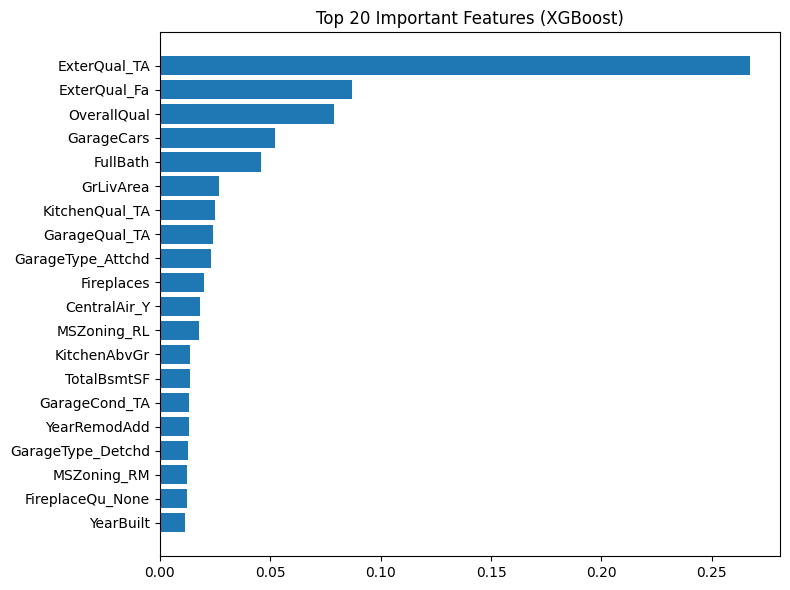

In [14]:
importances = best_model.feature_importances_
idx = np.argsort(importances)[-20:]

plt.figure(figsize=(8,6))
plt.barh(range(len(idx)), importances[idx], align="center")
plt.yticks(range(len(idx)), [X.columns[i] for i in idx])
plt.title("Top 20 Important Features (XGBoost)")
plt.tight_layout()
plt.show()

## 10) Findings & Reflections
- **Why log-RMSE?** Kaggle evaluates RMSE on log prices, making proportional errors count equally for cheap vs expensive houses.
- **Baseline vs Tuned:** Record your baseline log-RMSE and the tuned CV log-RMSE here.
- **Observations:** Which features dominate? Any data quality issues? Outliers?
- **Limitations:** Rare categories, heteroscedasticity, neighborhood effects.
- **Future Work:** Add engineered features (e.g., `TotalSF`), try LightGBM/CatBoost, remove outliers, stacking/blending.